In [ ]:
# Import libraries
import biom
import pandas as pd
import glob
from biom import Table, example_table
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import birdman.visualization as viz
import birdman.stats as stat
import birdman.diagnostics as diag
import arviz as az
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns 
import re
from pca import pca
import numpy as np
plt.style.use('fast')

In [2]:
# Import model results
model = az.from_netcdf("v_modelV4.nc")

In [3]:
model

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> observed_data

In [ ]:
# Compute summary statistics
diag.r2_score(model)

In [4]:
# Extract model posterior to dataframe
df = model.posterior[['covariate','feature_alr','beta_var']].to_dataframe()
df = df.groupby(['feature_alr','covariate']).mean().reset_index().pivot(index = 'feature_alr', columns = 'covariate', values = 'beta_var')
df

covariate,ETo,Intercept,Latitude,Precipitation,Rel_Hum,Temp_Max,Temp_Mean,Temp_Min,Vertebrate,Wind
feature_alr,,,,,,,,,,
007efea787a1c5a4474df418e9d09797,0.012619,-7.646106,-0.000396,-0.002128,0.002429,0.001522,-0.001013,0.006399,-0.023971,-0.006673
00c2a27315399ed2a603b2d140b53ca7,0.009854,-7.644864,-0.012780,0.012641,0.001150,-0.008091,-0.009876,-0.003079,-0.027318,-0.016532
0125cef46a97173190f9fbed9dd1e22b,-0.001376,-7.644253,-0.001933,0.002720,0.001287,-0.010991,-0.002301,-0.000741,-0.029725,-0.007603
012c72e7353edb50b5a1078a1a82bc0e,-0.007591,-7.598568,-0.007656,0.057278,-0.024449,-0.017589,-0.029179,-0.022465,0.030456,0.002077
013eac24471fe5484376c4bd78d205d6,-0.000725,-7.654333,-0.006014,0.003824,0.004139,-0.007818,-0.008609,-0.002544,-0.019839,-0.005440
...,...,...,...,...,...,...,...,...,...,...
ff884c3c9f0a65423e2458997b276f88,0.044010,-7.599975,-0.028973,-0.044108,-0.026155,0.005898,0.043773,0.039436,0.014760,-0.045588
ffa8f4fb4b8c219a58bef2e2db7bf27a,0.023695,-7.553637,0.031227,0.036654,-0.030169,0.080787,0.026378,-0.024348,-0.019173,-0.033473
ffb2f2dc4fe21b3d6f67a2579a7e51eb,0.001838,-7.652082,0.001831,-0.006715,0.001317,0.004253,-0.005614,0.006844,-0.029319,-0.004349


In [6]:
# Import feature taxonomy
tax = pd.read_csv('Sep_taxonomy.txt', delimiter = '\t')
tax['Phylum'] = tax['Phylum'].apply(lambda x: str(x)[4:]).apply(lambda x: 'Firmicutes' if x[0:10]=='Firmicutes' else x).apply(lambda x: 'Unknown' if x is None else x)
tax.head()

,Feature ID,Domain,Phylum,Class,Order,Family,Genus,Species
0,00003b7926ced7f40416b616ab1ccb04,d__Bacteria,Acidobacteriota,c__Acidobacteriae,o__Acidoferrales,f__UBA7541,g__Acidoferrum,NaN
1,00004539bcbb606c8282f1171595cc59,d__Bacteria,Firmicutes,c__Clostridia_258483,o__Oscillospirales,f__Ruminococcaceae,g__Faecalibacterium,s__Faecalibacterium prausnitzii_C_71351
2,000075b0eed00a9263fa7a183da00f03,d__Bacteria,Bacteroidota,c__Bacteroidia,o__Bacteroidales,f__Muribaculaceae,NaN,NaN
3,0000d1f717323fcf2922031d3db1e7c2,d__Bacteria,Actinobacteriota,c__Acidimicrobiia_401430,o__Acidimicrobiales,NaN,NaN,NaN
4,0000d61eb040fdba90342fb4b5735369,d__Bacteria,Actinobacteriota,c__Actinomycetia,o__Actinomycetales,NaN,NaN,NaN


In [7]:
# Merge differentials and taxonomy
diff = pd.merge(df, tax, left_index = True, right_on = 'Feature ID').set_index(['Domain','Phylum','Class','Order','Family','Genus','Species']).drop(columns = ['Feature ID','Intercept'])
diff

ETo  \
Domain      Phylum           Class                   Order                       Family                           Genus             Species             
d__Bacteria Bacteroidota      c__Bacteroidia          o__Bacteroidales            f__Muribaculaceae               NaN               NaN      0.012619   
                                                      o__Flavobacteriales_877923  f__Flavobacteriaceae            NaN               NaN      0.009854   
                             NaN                     NaN                         NaN                              NaN               NaN     -0.001376   
            Proteobacteria    c__Gammaproteobacteria  o__Pseudomonadales_660879   f__Moraxellaceae                 g__Acinetobacter NaN     -0.007591   
            Actinobacteriota  c__Actinomycetia       NaN                         NaN                              NaN               NaN     -0.000725   
...                                                                                                                                               ...   
                             NaN                     NaN                         NaN                              NaN               NaN      0.044010   
                                                                                                                                    NaN      0.023695   
            Planctomycetota   c__Planctomycetia      NaN                         NaN                              NaN               NaN      0.001838   
            Firmicutes        c__Clostridia_258483    o__Peptostreptococcales     f__Peptostreptococcaceae_256921 NaN               NaN      0.111453   
            Proteobacteria    c__Alphaproteobacteria  o__Rhodobacterales          f__Rhodobacteraceae              g__Paracoccus    NaN     -0.015296   

                                                                                                                                             Latitude  \
Domain      Phylum           Class                   Order                       Family                           Genus             Species             
d__Bacteria Bacteroidota      c__Bacteroidia          o__Bacteroidales            f__Muribaculaceae               NaN               NaN     -0.000396   
                                                      o__Flavobacteriales_877923  f__Flavobacteriaceae            NaN               NaN     -0.012780   
                             NaN                     NaN                         NaN                              NaN               NaN     -0.001933   
            Proteobacteria    c__Gammaproteobacteria  o__Pseudomonadales_660879   f__Moraxellaceae                 g__Acinetobacter NaN     -0.007656   
            Actinobacteriota  c__Actinomycetia       NaN                         NaN                              NaN               NaN     -0.006014   
...                                                                                                                                               ...   
                             NaN                     NaN                         NaN                              NaN               NaN     -0.028973   
                                                                                                                                    NaN      0.031227   
            Planctomycetota   c__Planctomycetia      NaN                         NaN                              NaN               NaN      0.001831   
            Firmicutes        c__Clostridia_258483    o__Peptostreptococcales     f__Peptostreptococcaceae_256921 NaN               NaN     -0.033124   
            Proteobacteria    c__Alphaproteobacteria  o__Rhodobacterales          f__Rhodobacteraceae              g__Paracoccus    NaN      0.003806   

                                                                                                                                             Precipitation  \
Domain  

In [8]:
# Generate pca dataframe
pca = PCA(n_components=2)
pc_df = pd.DataFrame(data = pca.fit_transform(diff), columns = ['PC1','PC2'])
l = pca.components_.T

In [9]:
# Get explained variance by principal component
exp = pca.explained_variance_ratio_
print('PC1 Explained Variance: ' + str(exp[0]))
print('PC2 Explained Variance: ' + str(exp[1]))

PC1 Explained Variance: 0.4532370322080421
PC2 Explained Variance: 0.19700449740179515


In [10]:
# Generate color palette for plot
palette = sns.color_palette("bright", n_colors=10)
palette = palette[0:7] + palette[8:]

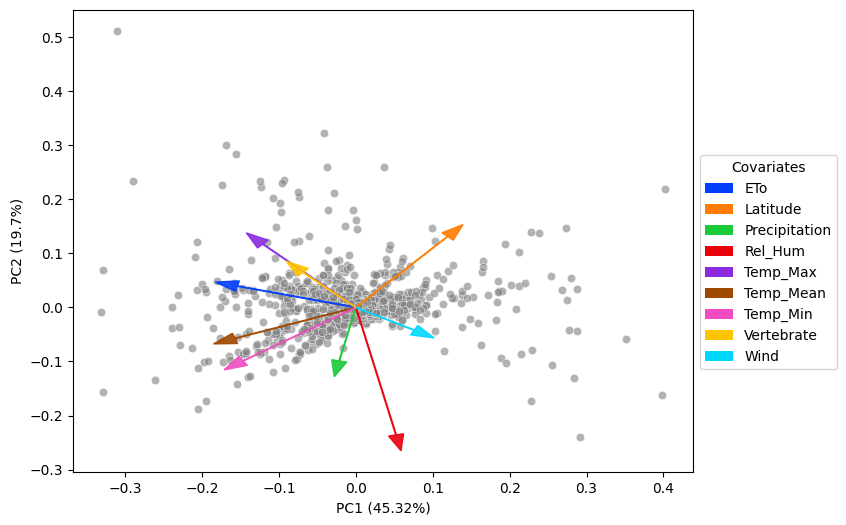

In [11]:
# PCA Biplot not using microbe phylogeny
from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(x = pc_df['PC1'], y = pc_df['PC2'], color = 'gray', alpha = 0.6)
leg_cov = []
for i, feature in enumerate(diff.columns):
    ax.arrow(x=0, y=0, dx=l[i, 0]*0.4, dy=l[i, 1]*0.4, 
             alpha = 0.9,
             head_width = 0.02,  
             edgecolor = palette[i], 
             facecolor = palette[i],
             linestyle = '-',
             length_includes_head = True)
    leg_cov.append(Patch(facecolor = palette[i], label = feature))
plt.xlabel('PC1 (' + str(round(100*exp[0], 2)) + '%)')
plt.ylabel('PC2 (' + str(round(100*exp[1], 2)) + '%)')
#legend_elements = [Line2D([0], [0], color='Red', label='Model Using P'),
                   #Line2D([0], [0], color='Purple', label='Model Using P, Quadratic, and Cubic Terms')]
ax.legend(
    handles = leg_cov,
    title = 'Covariates',
    bbox_to_anchor = [1.0, 0.7],
    ncol = 1
)


In [12]:
# Generate new color palette
pal = sns.color_palette('husl')
pal[2] = (0.5, 0.5, 0.5)
phy = diff.reset_index()['Phylum']
phy = phy.apply(lambda x: 'Other' if x=='Verrucomicrobiota' else x)

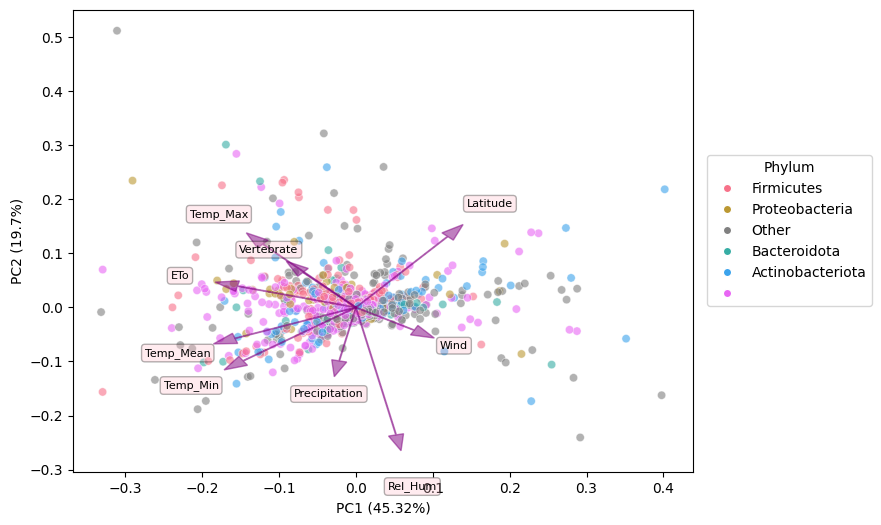

In [ ]:
# PCA Biplot with microbe phylogeny
from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(x = pc_df['PC1'], y = pc_df['PC2'], color = 'gray', hue = phy.apply(lambda x: x if phy.value_counts()[x] > 100 else 'Other'), palette = pal, alpha = 0.6)
leg_cov = []
for i, feature in enumerate(diff.columns):
    ax.arrow(x=0, y=0, dx=l[i, 0]*0.4, dy=l[i, 1]*0.4, 
             alpha = 0.5,
             head_width = 0.02,  
             edgecolor = 'purple', 
             facecolor = 'purple',
             linestyle = '-',
             length_includes_head = True,
             label = feature)
    ax.annotate(feature, xy=(l[i, 0]*0.4, l[i, 1]*0.4), xytext=(l[i, 0]*0.5, l[i, 1]*0.5),
        ha='center', va='center', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', fc='pink', alpha=0.3))    
    leg_cov.append(Patch(facecolor = palette[i], label = feature))
plt.xlabel('PC1 (' + str(round(100*exp[0], 2)) + '%)')
plt.ylabel('PC2 (' + str(round(100*exp[1], 2)) + '%)')
ax.legend(
    handles = leg_cov,
    title = 'Covariates',
    bbox_to_anchor = [1.3, 0.7],
    ncol = 1
)
legend_elements = []
for p, col in zip(phy.apply(lambda x: x if phy.value_counts()[x] > 100 else 'Other').value_counts().index, pal):
    legend_elements.append(Line2D([0],[0], marker = 'o', color = 'w', label = p, markerfacecolor = col))
ax.legend(handles = legend_elements, title = 'Phylum', bbox_to_anchor = [1.3, 0.7])
plt.show()

In [16]:
# Group differentials by genus
diff_g = diff.groupby('Genus').mean()
diff_g = diff_g[['ETo', 'Precipitation', 'Rel_Hum','Temp_Max', 'Temp_Mean', 'Temp_Min', 'Wind']]
diff_g

,ETo,Precipitation,Rel_Hum,Temp_Max,Temp_Mean,Temp_Min,Wind
Genus,,,,,,,
g__,-0.005993,0.001268,0.004219,-0.003493,-0.004294,-0.007033,-0.000770
g__1-14-0-20-46-22,-0.011404,0.001700,0.003462,-0.013187,-0.006284,-0.005280,0.006232
g__41T-STBD-0c-01a,-0.001936,-0.001376,-0.000207,-0.009446,-0.005049,-0.003703,0.004920
g__67-14,-0.012182,-0.013977,0.006294,-0.001535,-0.013574,-0.004408,-0.004655
g__Acetatifactor,-0.001430,0.016130,0.011900,0.000451,0.008719,0.010367,-0.017169
...,...,...,...,...,...,...,...
g__Xanthomonas_A_614439,0.007664,0.026115,0.011639,0.007008,0.018158,0.017661,-0.029887
g__YD0425bin50,-0.001061,0.005237,0.013907,-0.002455,-0.004614,0.001432,-0.005222
g__Yoonia_491068,-0.002998,-0.001060,0.013686,-0.005923,-0.000002,0.000414,-0.002383


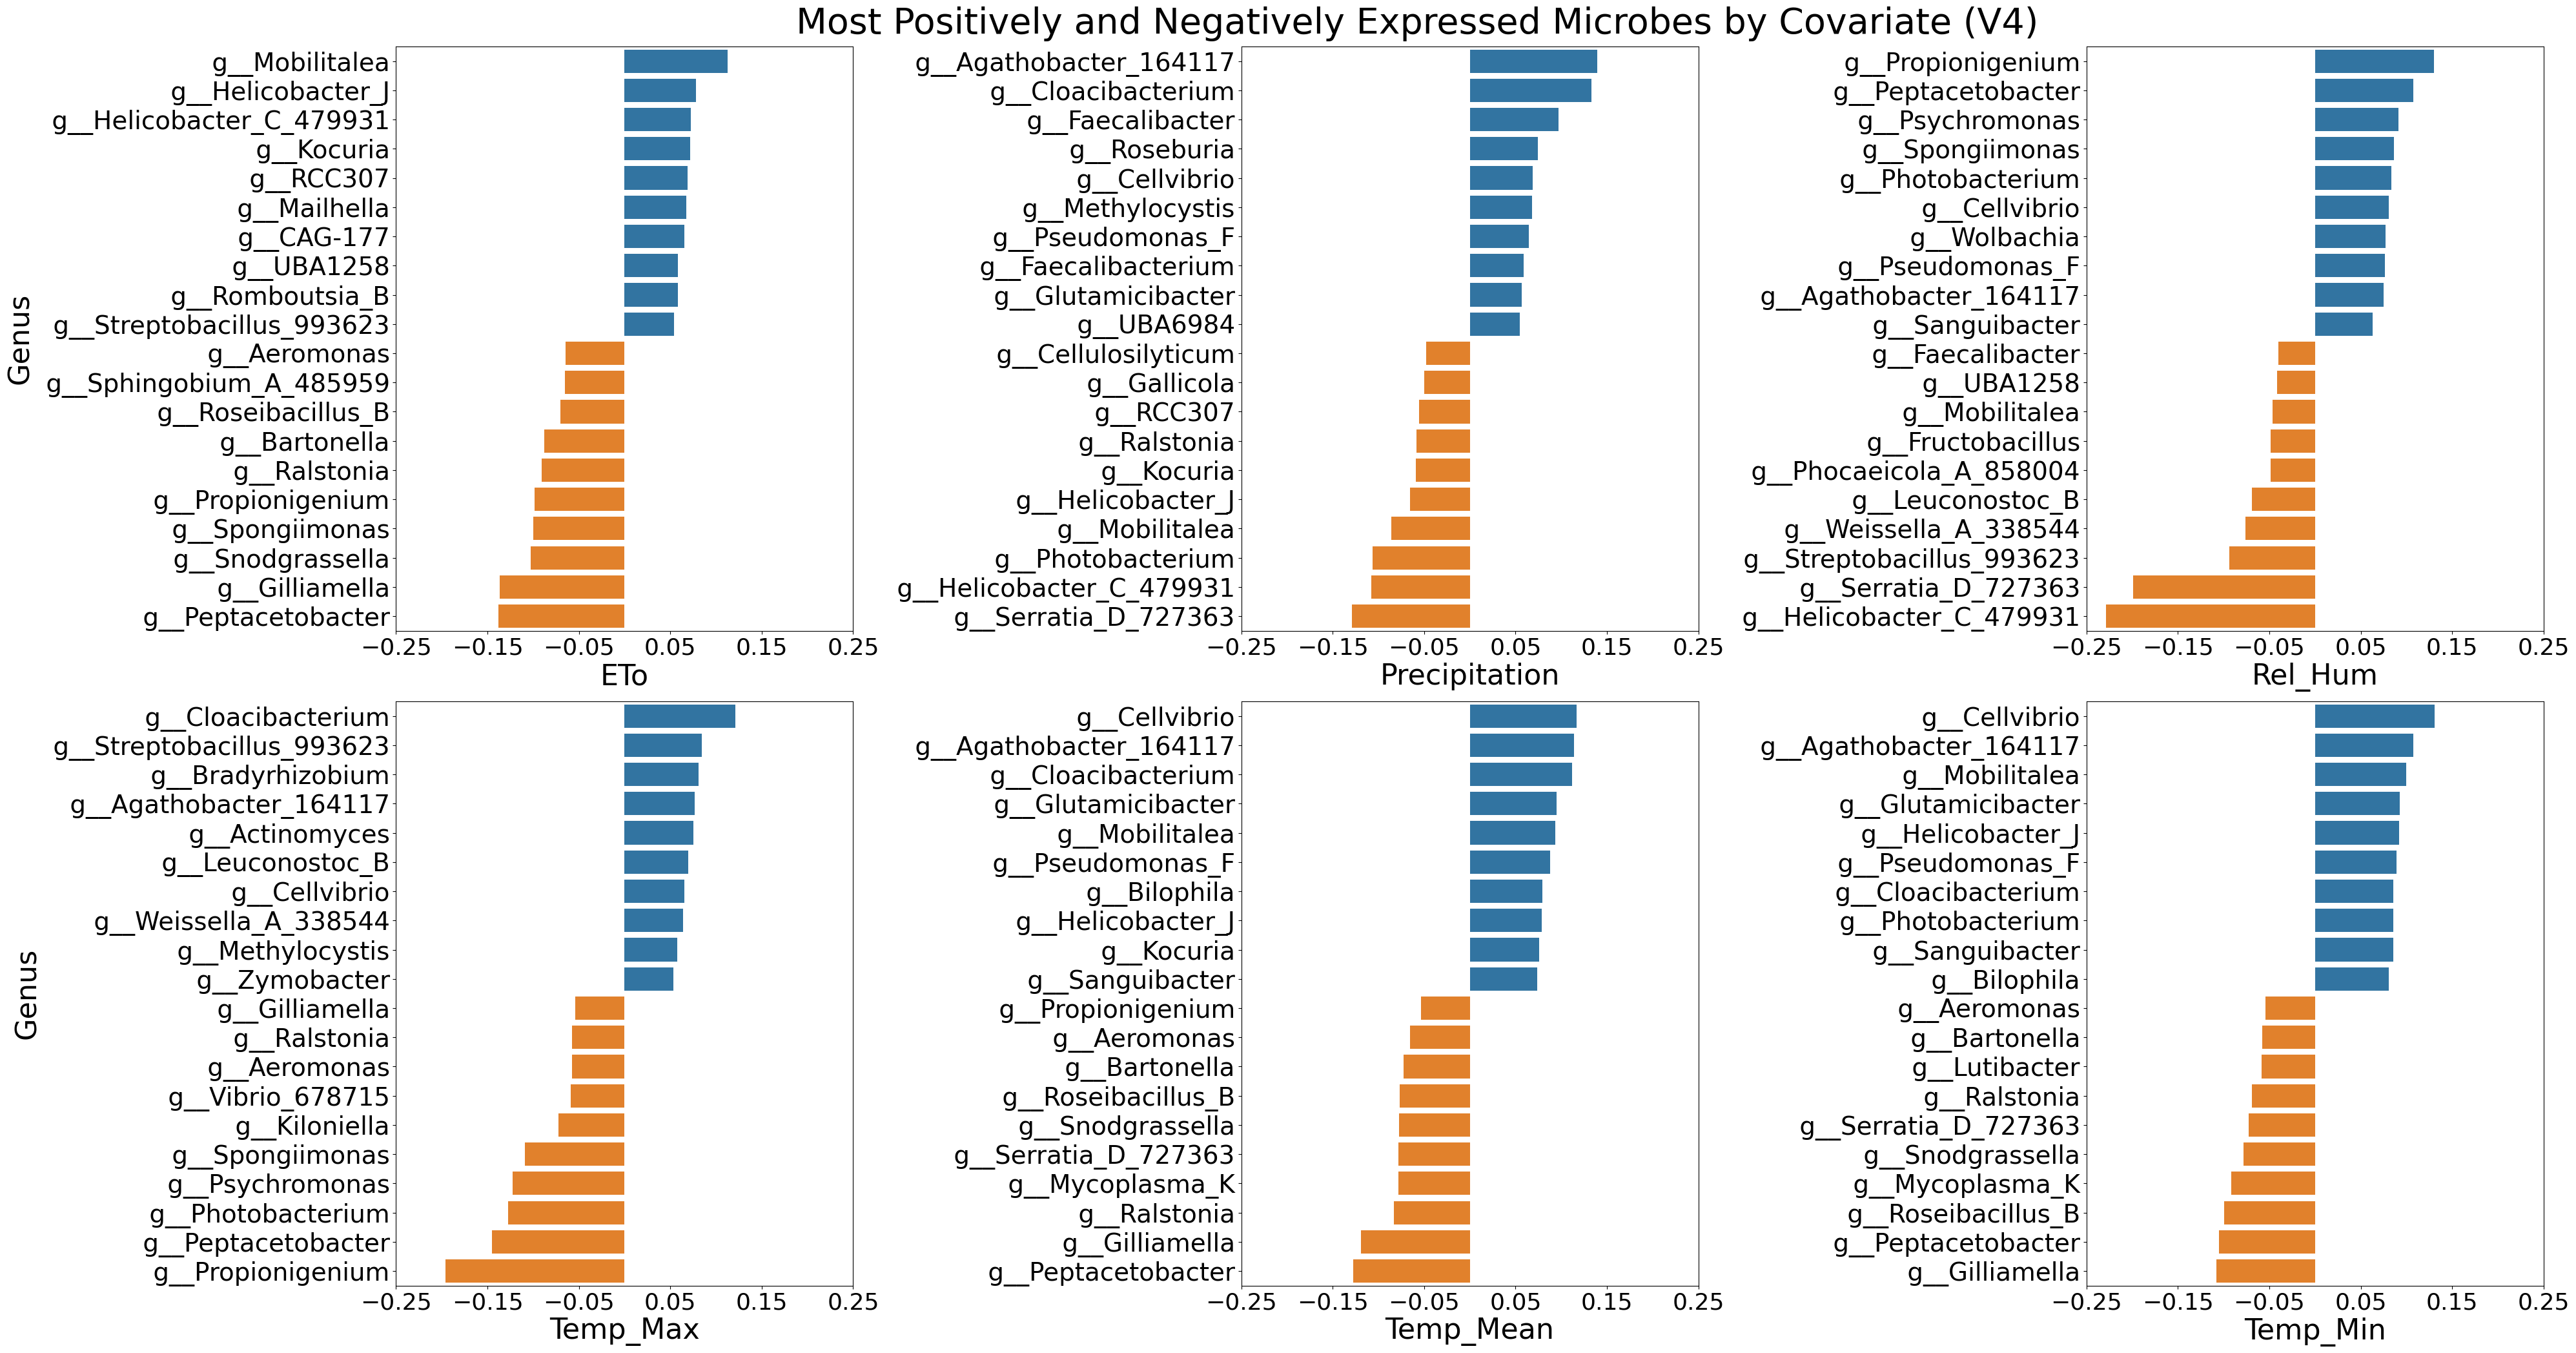

In [ ]:
# Plot 10 most positively and negatively expressed microbes by covariate
fig, axes = plt.subplots(2, 3, figsize=(40, 22))
axes = axes.flatten()
for i, ax in enumerate(axes):
    cov = diff_g.columns[i]
    sns.barplot(x = cov, data = diff_g.sort_values(by=cov, ascending = False).iloc[0:10,:], y = 'Genus', ax = ax)
    sns.barplot(x = cov, data = diff.groupby('Genus').mean().sort_values(by=cov, ascending = True).iloc[0:10,:].sort_values(by=cov, ascending = False), y = 'Genus', ax = ax)
    ax.set_xlabel(cov, fontsize=32)
    ax.set_xticks([-0.25,-0.15,-0.05,0.05,0.15,0.25])
    ax.set_ylabel('Genus', fontsize=32)
    ax.tick_params(axis='y',labelsize=28)
    ax.tick_params(axis='x',labelsize=26)
    if i % 3 != 0:
        ax.set_ylabel('')
plt.suptitle('Most Positively and Negatively Expressed Microbes by Covariate (V4)', x=0.55, y = 0.95, fontsize=40)
plt.tight_layout(rect=[0,0,1,0.96])

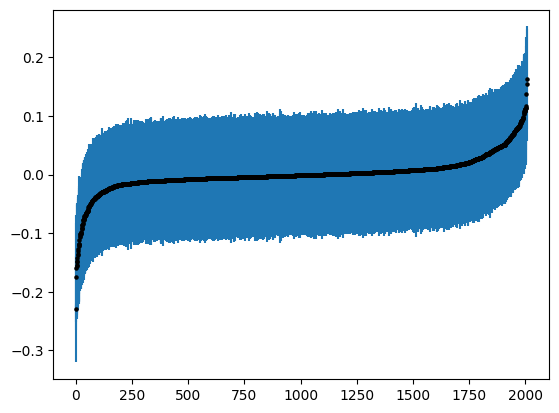

In [ ]:
# Plot parameter estimates of Temp_Mean
import birdman.visualization as viz
ax = viz.plot_parameter_estimates(
    model,
    parameter="beta_var",
    coords={"covariate": "Temp_Mean"},
)


In [ ]:
# Import libraries for identifying significant microbes
from matplotlib_venn import venn3
from upsetplot import UpSet
from filtering_significance import filter_significance
from collections import Counter

In [23]:
# Process results to dataframe w/ confidence intervals
def process_dataframe(df, feat_id, suffix=""):
        df = df.copy()
        df.reset_index(inplace=True, drop=True)
        df.columns.name = ""
        df.index = feat_id
        df.columns = [x + suffix for x in df.columns]
        return df

def reformat_multiindex(df, feat_id, suffix=""):
    df = df.copy().reset_index()
    new_df = pd.DataFrame(columns=df.covariate.unique(), index=feat_id)
    for c in new_df.columns: 
        lower = df.loc[(df['covariate'] == c) & (df['hdi'] == 'lower')]['beta_var'].values
        higher = df.loc[(df['covariate'] == c) & (df['hdi'] == 'higher')]['beta_var'].values
        new_df[c + '_lower'] = lower
        new_df[c + '_upper'] = higher
    new_df.columns = [c + suffix for c in new_df.columns]
    return new_df

this_feat_id = list(model.posterior['feature_alr'].to_dataframe().index)
this_feat_diff = model.posterior["beta_var"]
this_feat_diff_mean = this_feat_diff.mean(["chain", "draw"]).to_dataframe().reset_index().pivot(index='feature_alr',columns='covariate', values='beta_var')
this_feat_diff_std = this_feat_diff.std(["chain", "draw"]).to_dataframe().reset_index().pivot(index='feature_alr',columns='covariate', values='beta_var')
this_feat_diff_hdi = az.hdi(this_feat_diff, hdi_prob=0.90).to_dataframe()

this_feat_diff_mean = process_dataframe(
this_feat_diff_mean,
this_feat_id,
    suffix="_mean"
)
this_feat_diff_std = process_dataframe(
    this_feat_diff_std,
    this_feat_id,
    suffix="_std"
)
this_feat_diff_hdis = reformat_multiindex(
    this_feat_diff_hdi,
    this_feat_id, 
    suffix='_hdi'
)
interval_df = pd.concat(
    [this_feat_diff_mean, this_feat_diff_std, this_feat_diff_hdis],
    axis=1
)

interval_df.index.name = "Feature"
interval_df

,ETo_mean,Intercept_mean,Latitude_mean,Precipitation_mean,Rel_Hum_mean,Temp_Max_mean,Temp_Mean_mean,Temp_Min_mean,Vertebrate_mean,Wind_mean,...,Precipitation_lower_hdi,Precipitation_upper_hdi,ETo_lower_hdi,ETo_upper_hdi,Rel_Hum_lower_hdi,Rel_Hum_upper_hdi,Wind_lower_hdi,Wind_upper_hdi,Vertebrate_lower_hdi,Vertebrate_upper_hdi
Feature,,,,,,,,,,,,,,,,,,,,,
007efea787a1c5a4474df418e9d09797,0.012619,-7.646106,-0.000396,-0.002128,0.002429,0.001522,-0.001013,0.006399,-0.023971,-0.006673,...,-0.153757,0.161411,-0.156024,0.167799,-0.148502,0.169238,-0.165078,0.149048,-0.175045,0.141013
00c2a27315399ed2a603b2d140b53ca7,0.009854,-7.644864,-0.012780,0.012641,0.001150,-0.008091,-0.009876,-0.003079,-0.027318,-0.016532,...,-0.129846,0.170919,-0.132424,0.184882,-0.162574,0.154067,-0.177817,0.145205,-0.202766,0.119494
0125cef46a97173190f9fbed9dd1e22b,-0.001376,-7.644253,-0.001933,0.002720,0.001287,-0.010991,-0.002301,-0.000741,-0.029725,-0.007603,...,-0.147100,0.172728,-0.155927,0.153276,-0.158156,0.153032,-0.154339,0.165142,-0.186462,0.133821
012c72e7353edb50b5a1078a1a82bc0e,-0.007591,-7.598568,-0.007656,0.057278,-0.024449,-0.017589,-0.029179,-0.022465,0.030456,0.002077,...,-0.090886,0.226568,-0.160324,0.149825,-0.201086,0.116958,-0.151829,0.170942,-0.107167,0.204995
013eac24471fe5484376c4bd78d205d6,-0.000725,-7.654333,-0.006014,0.003824,0.004139,-0.007818,-0.008609,-0.002544,-0.019839,-0.005440,...,-0.180982,0.156959,-0.179932,0.164039,-0.166802,0.153456,-0.164515,0.148441,-0.163186,0.146929
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ff884c3c9f0a65423e2458997b276f88,0.044010,-7.599975,-0.028973,-0.044108,-0.026155,0.005898,0.043773,0.039436,0.014760,-0.045588,...,-0.214308,0.116896,-0.113257,0.192759,-0.191559,0.121101,-0.201289,0.123068,-0.127060,0.167818
ffa8f4fb4b8c219a58bef2e2db7bf27a,0.023695,-7.553637,0.031227,0.036654,-0.030169,0.080787,0.026378,-0.024348,-0.019173,-0.033473,...,-0.106722,0.205184,-0.149152,0.166357,-0.176944,0.127912,-0.179757,0.136553,-0.167963,0.141338
ffb2f2dc4fe21b3d6f67a2579a7e51eb,0.001838,-7.652082,0.001831,-0.006715,0.001317,0.004253,-0.005614,0.006844,-0.029319,-0.004349,...,-0.184268,0.160193,-0.164460,0.150964,-0.164079,0.147915,-0.162199,0.131875,-0.191477,0.129743


In [24]:
# Merge confidence intervals and taxonomy
conf = pd.merge(interval_df, tax, left_index = True, right_on = 'Feature ID').set_index(['Domain','Phylum','Class','Order','Family','Genus','Species']).drop(columns = ['Feature ID'])
conf

ETo_mean  \
Domain      Phylum           Class                   Order                       Family                           Genus             Species             
d__Bacteria Bacteroidota      c__Bacteroidia          o__Bacteroidales            f__Muribaculaceae               NaN               NaN      0.012619   
                                                      o__Flavobacteriales_877923  f__Flavobacteriaceae            NaN               NaN      0.009854   
                             NaN                     NaN                         NaN                              NaN               NaN     -0.001376   
            Proteobacteria    c__Gammaproteobacteria  o__Pseudomonadales_660879   f__Moraxellaceae                 g__Acinetobacter NaN     -0.007591   
            Actinobacteriota  c__Actinomycetia       NaN                         NaN                              NaN               NaN     -0.000725   
...                                                                                                                                               ...   
                             NaN                     NaN                         NaN                              NaN               NaN      0.044010   
                                                                                                                                    NaN      0.023695   
            Planctomycetota   c__Planctomycetia      NaN                         NaN                              NaN               NaN      0.001838   
            Firmicutes        c__Clostridia_258483    o__Peptostreptococcales     f__Peptostreptococcaceae_256921 NaN               NaN      0.111453   
            Proteobacteria    c__Alphaproteobacteria  o__Rhodobacterales          f__Rhodobacteraceae              g__Paracoccus    NaN     -0.015296   

                                                                                                                                             Intercept_mean  \
Domain      Phylum           Class                   Order                       Family                           Genus             Species                   
d__Bacteria Bacteroidota      c__Bacteroidia          o__Bacteroidales            f__Muribaculaceae               NaN               NaN           -7.646106   
                                                      o__Flavobacteriales_877923  f__Flavobacteriaceae            NaN               NaN           -7.644864   
                             NaN                     NaN                         NaN                              NaN               NaN           -7.644253   
            Proteobacteria    c__Gammaproteobacteria  o__Pseudomonadales_660879   f__Moraxellaceae                 g__Acinetobacter NaN           -7.598568   
            Actinobacteriota  c__Actinomycetia       NaN                         NaN                              NaN               NaN           -7.654333   
...                                                                                                                                                     ...   
                             NaN                     NaN                         NaN                              NaN               NaN           -7.599975   
                                                                                                                                    NaN           -7.553637   
            Planctomycetota   c__Planctomycetia      NaN                         NaN                              NaN               NaN           -7.652082   
            Firmicutes        c__Clostridia_258483    o__Peptostreptococcales     f__Peptostreptococcaceae_256921 NaN               NaN           -7.580991   
            Proteobacteria    c__Alphaproteobacteria  o__Rhodobacterales          f__Rhodobacteraceae              g__Paracoccus    NaN           -7.664135   

                                                                                   

In [ ]:
# Reset index and aggregate features into one column
conf_reset = conf.reset_index()
conf_reset['Feature'] = conf_reset.apply(
    lambda row: ';'.join(row[:-1].astype(str)), axis=1
)
conf_reset = conf_reset.iloc[:,7:]
conf_reset

,ETo_mean,Intercept_mean,Latitude_mean,Precipitation_mean,Rel_Hum_mean,Temp_Max_mean,Temp_Mean_mean,Temp_Min_mean,Vertebrate_mean,Wind_mean,...,Precipitation_upper_hdi,ETo_lower_hdi,ETo_upper_hdi,Rel_Hum_lower_hdi,Rel_Hum_upper_hdi,Wind_lower_hdi,Wind_upper_hdi,Vertebrate_lower_hdi,Vertebrate_upper_hdi,Feature
0,0.012619,-7.646106,-0.000396,-0.002128,0.002429,0.001522,-0.001013,0.006399,-0.023971,-0.006673,...,0.161411,-0.156024,0.167799,-0.148502,0.169238,-0.165078,0.149048,-0.175045,0.141013,d__Bacteria;Bacteroidota; c__Bacteroidia; o__B...
1,0.009854,-7.644864,-0.012780,0.012641,0.001150,-0.008091,-0.009876,-0.003079,-0.027318,-0.016532,...,0.170919,-0.132424,0.184882,-0.162574,0.154067,-0.177817,0.145205,-0.202766,0.119494,d__Bacteria;Bacteroidota; c__Bacteroidia; o__F...
2,-0.001376,-7.644253,-0.001933,0.002720,0.001287,-0.010991,-0.002301,-0.000741,-0.029725,-0.007603,...,0.172728,-0.155927,0.153276,-0.158156,0.153032,-0.154339,0.165142,-0.186462,0.133821,d__Bacteria;;nan;nan;nan;nan;nan;-0.0013761034...
3,-0.007591,-7.598568,-0.007656,0.057278,-0.024449,-0.017589,-0.029179,-0.022465,0.030456,0.002077,...,0.226568,-0.160324,0.149825,-0.201086,0.116958,-0.151829,0.170942,-0.107167,0.204995,d__Bacteria;Proteobacteria; c__Gammaproteobact...
4,-0.000725,-7.654333,-0.006014,0.003824,0.004139,-0.007818,-0.008609,-0.002544,-0.019839,-0.005440,...,0.156959,-0.179932,0.164039,-0.166802,0.153456,-0.164515,0.148441,-0.163186,0.146929,d__Bacteria;Actinobacteriota; c__Actinomycetia...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2002,0.044010,-7.599975,-0.028973,-0.044108,-0.026155,0.005898,0.043773,0.039436,0.014760,-0.045588,...,0.116896,-0.113257,0.192759,-0.191559,0.121101,-0.201289,0.123068,-0.127060,0.167818,d__Bacteria;;nan;nan;nan;nan;nan;0.04401032133...
2003,0.023695,-7.553637,0.031227,0.036654,-0.030169,0.080787,0.026378,-0.024348,-0.019173,-0.033473,...,0.205184,-0.149152,0.166357,-0.176944,0.127912,-0.179757,0.136553,-0.167963,0.141338,d__Bacteria;;nan;nan;nan;nan;nan;0.02369462215...
2004,0.001838,-7.652082,0.001831,-0.006715,0.001317,0.004253,-0.005614,0.006844,-0.029319,-0.004349,...,0.160193,-0.164460,0.150964,-0.164079,0.147915,-0.162199,0.131875,-0.191477,0.129743,d__Bacteria;Planctomycetota; c__Planctomycetia...
2005,0.111453,-7.580991,-0.033124,0.059236,0.082206,0.027849,0.096528,0.093206,0.047055,0.206793,...,0.204296,-0.049808,0.239727,-0.074727,0.266800,0.086994,0.326358,-0.103085,0.190685,d__Bacteria;Firmicutes; c__Clostridia_258483; ...


In [ ]:
# Filter to identify statistically significant microbes
col_order = conf_reset.columns[0:len(model.posterior.covariate.data)]
col_order = [s[:-5] for s in col_order]
col_order

top_negative = {}
top_positive = {}
sig = {}

for i,cov in enumerate(col_order):
    
    sig[cov], top_positive[cov], top_negative[cov] = filter_significance(conf_reset,column=i, top_40=False)

Test column: ETo
Total features before filtering: 2007
Significant features: 13
372    -0.289097
449     0.035539
493    -0.277852
544    -0.273228
623    -0.315314
992    -0.353923
1014   -0.338622
1195    0.004636
1456   -0.285039
1520    0.069684
1562   -0.381286
1598   -0.313021
1927   -0.310290
Name: lower_hdi, dtype: float64
Top Features: 3
Bottom Features: 10
Test column: Intercept
Total features before filtering: 2007
Significant features: 2007
0      -7.80549
1      -7.78735
2      -7.78914
3      -7.74799
4      -7.80380
         ...   
2002   -7.76386
2003   -7.72396
2004   -7.81401
2005   -7.71332
2006   -7.83411
Name: lower_hdi, Length: 2007, dtype: float64
Top Features: 0
Bottom Features: 2007
Test column: Latitude
Total features before filtering: 2007
Significant features: 17
41     -0.345104
133    -0.298827
168    -0.306184
391    -0.313480
586    -0.309803
601    -0.312517
963    -0.299505
992     0.044199
1195   -0.311036
1270   -0.319653
1562    0.000938
1616   -0.3

In [ ]:
# Count significant microbes by covariate
for key, value in sig.items():
    print([key, value.shape[0]])

['ETo', 13]
['Intercept', 2007]
['Latitude', 17]
['Precipitation', 5]
['Rel_Hum', 16]
['Temp_Max', 24]
['Temp_Mean', 8]
['Temp_Min', 7]
['Vertebrate', 5]
['Wind', 22]


[' g__Mobilitalea', ' g__Helicobacter_J', ' g__Helicobacter_C_479931', ' g__Kocuria', ' g__RCC307', ' g__Mailhella', ' g__CAG-177', ' g__UBA1258', ' g__Romboutsia_B', ' g__Streptobacillus_993623', ' g__Aeromonas', ' g__Sphingobium_A_485959', ' g__Roseibacillus_B', ' g__Bartonella', ' g__Ralstonia', ' g__Propionigenium', ' g__Spongiimonas', ' g__Snodgrassella', ' g__Gilliamella', ' g__Peptacetobacter']
[' g__Agathobacter_164117', ' g__Cloacibacterium', ' g__Faecalibacter', ' g__Roseburia', ' g__Cellvibrio', ' g__Methylocystis', ' g__Pseudomonas_F', ' g__Faecalibacterium', ' g__Glutamicibacter', ' g__UBA6984', ' g__Cellulosilyticum', ' g__Gallicola', ' g__RCC307', ' g__Ralstonia', ' g__Kocuria', ' g__Helicobacter_J', ' g__Mobilitalea', ' g__Photobacterium', ' g__Helicobacter_C_479931', ' g__Serratia_D_727363']
[' g__Propionigenium', ' g__Peptacetobacter', ' g__Psychromonas', ' g__Spongiimonas', ' g__Photobacterium', ' g__Cellvibrio', ' g__Wolbachia', ' g__Pseudomonas_F', ' g__Agathobacte

/tmp/ipykernel_6154/3076163420.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cur_y_ticks)
/tmp/ipykernel_6154/3076163420.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cur_y_ticks)
/tmp/ipykernel_6154/3076163420.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cur_y_ticks)


[' g__Cloacibacterium', ' g__Streptobacillus_993623', ' g__Bradyrhizobium', ' g__Agathobacter_164117', ' g__Actinomyces', ' g__Leuconostoc_B', ' g__Cellvibrio', ' g__Weissella_A_338544', ' g__Methylocystis', ' g__Zymobacter', ' g__Gilliamella', ' g__Ralstonia', ' g__Aeromonas', ' g__Vibrio_678715', ' g__Kiloniella', ' g__Spongiimonas', ' g__Psychromonas', ' g__Photobacterium', ' g__Peptacetobacter', ' g__Propionigenium']


/tmp/ipykernel_6154/3076163420.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cur_y_ticks)


[' g__Cellvibrio', ' g__Agathobacter_164117', ' g__Cloacibacterium', ' g__Glutamicibacter', ' g__Mobilitalea', ' g__Pseudomonas_F', ' g__Bilophila', ' g__Helicobacter_J', ' g__Kocuria', ' g__Sanguibacter', ' g__Propionigenium', ' g__Aeromonas', ' g__Bartonella', ' g__Roseibacillus_B', ' g__Snodgrassella', ' g__Serratia_D_727363', ' g__Mycoplasma_K', ' g__Ralstonia', ' g__Gilliamella', ' g__Peptacetobacter']
[' g__Cellvibrio', ' g__Agathobacter_164117', ' g__Mobilitalea', ' g__Glutamicibacter', ' g__Helicobacter_J', ' g__Pseudomonas_F', ' g__Cloacibacterium', ' g__Photobacterium', ' g__Sanguibacter', ' g__Bilophila', ' g__Aeromonas', ' g__Bartonella', ' g__Lutibacter', ' g__Ralstonia', ' g__Serratia_D_727363', ' g__Snodgrassella', ' g__Mycoplasma_K', ' g__Roseibacillus_B', ' g__Peptacetobacter', ' g__Gilliamella']


/tmp/ipykernel_6154/3076163420.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cur_y_ticks)
/tmp/ipykernel_6154/3076163420.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cur_y_ticks)


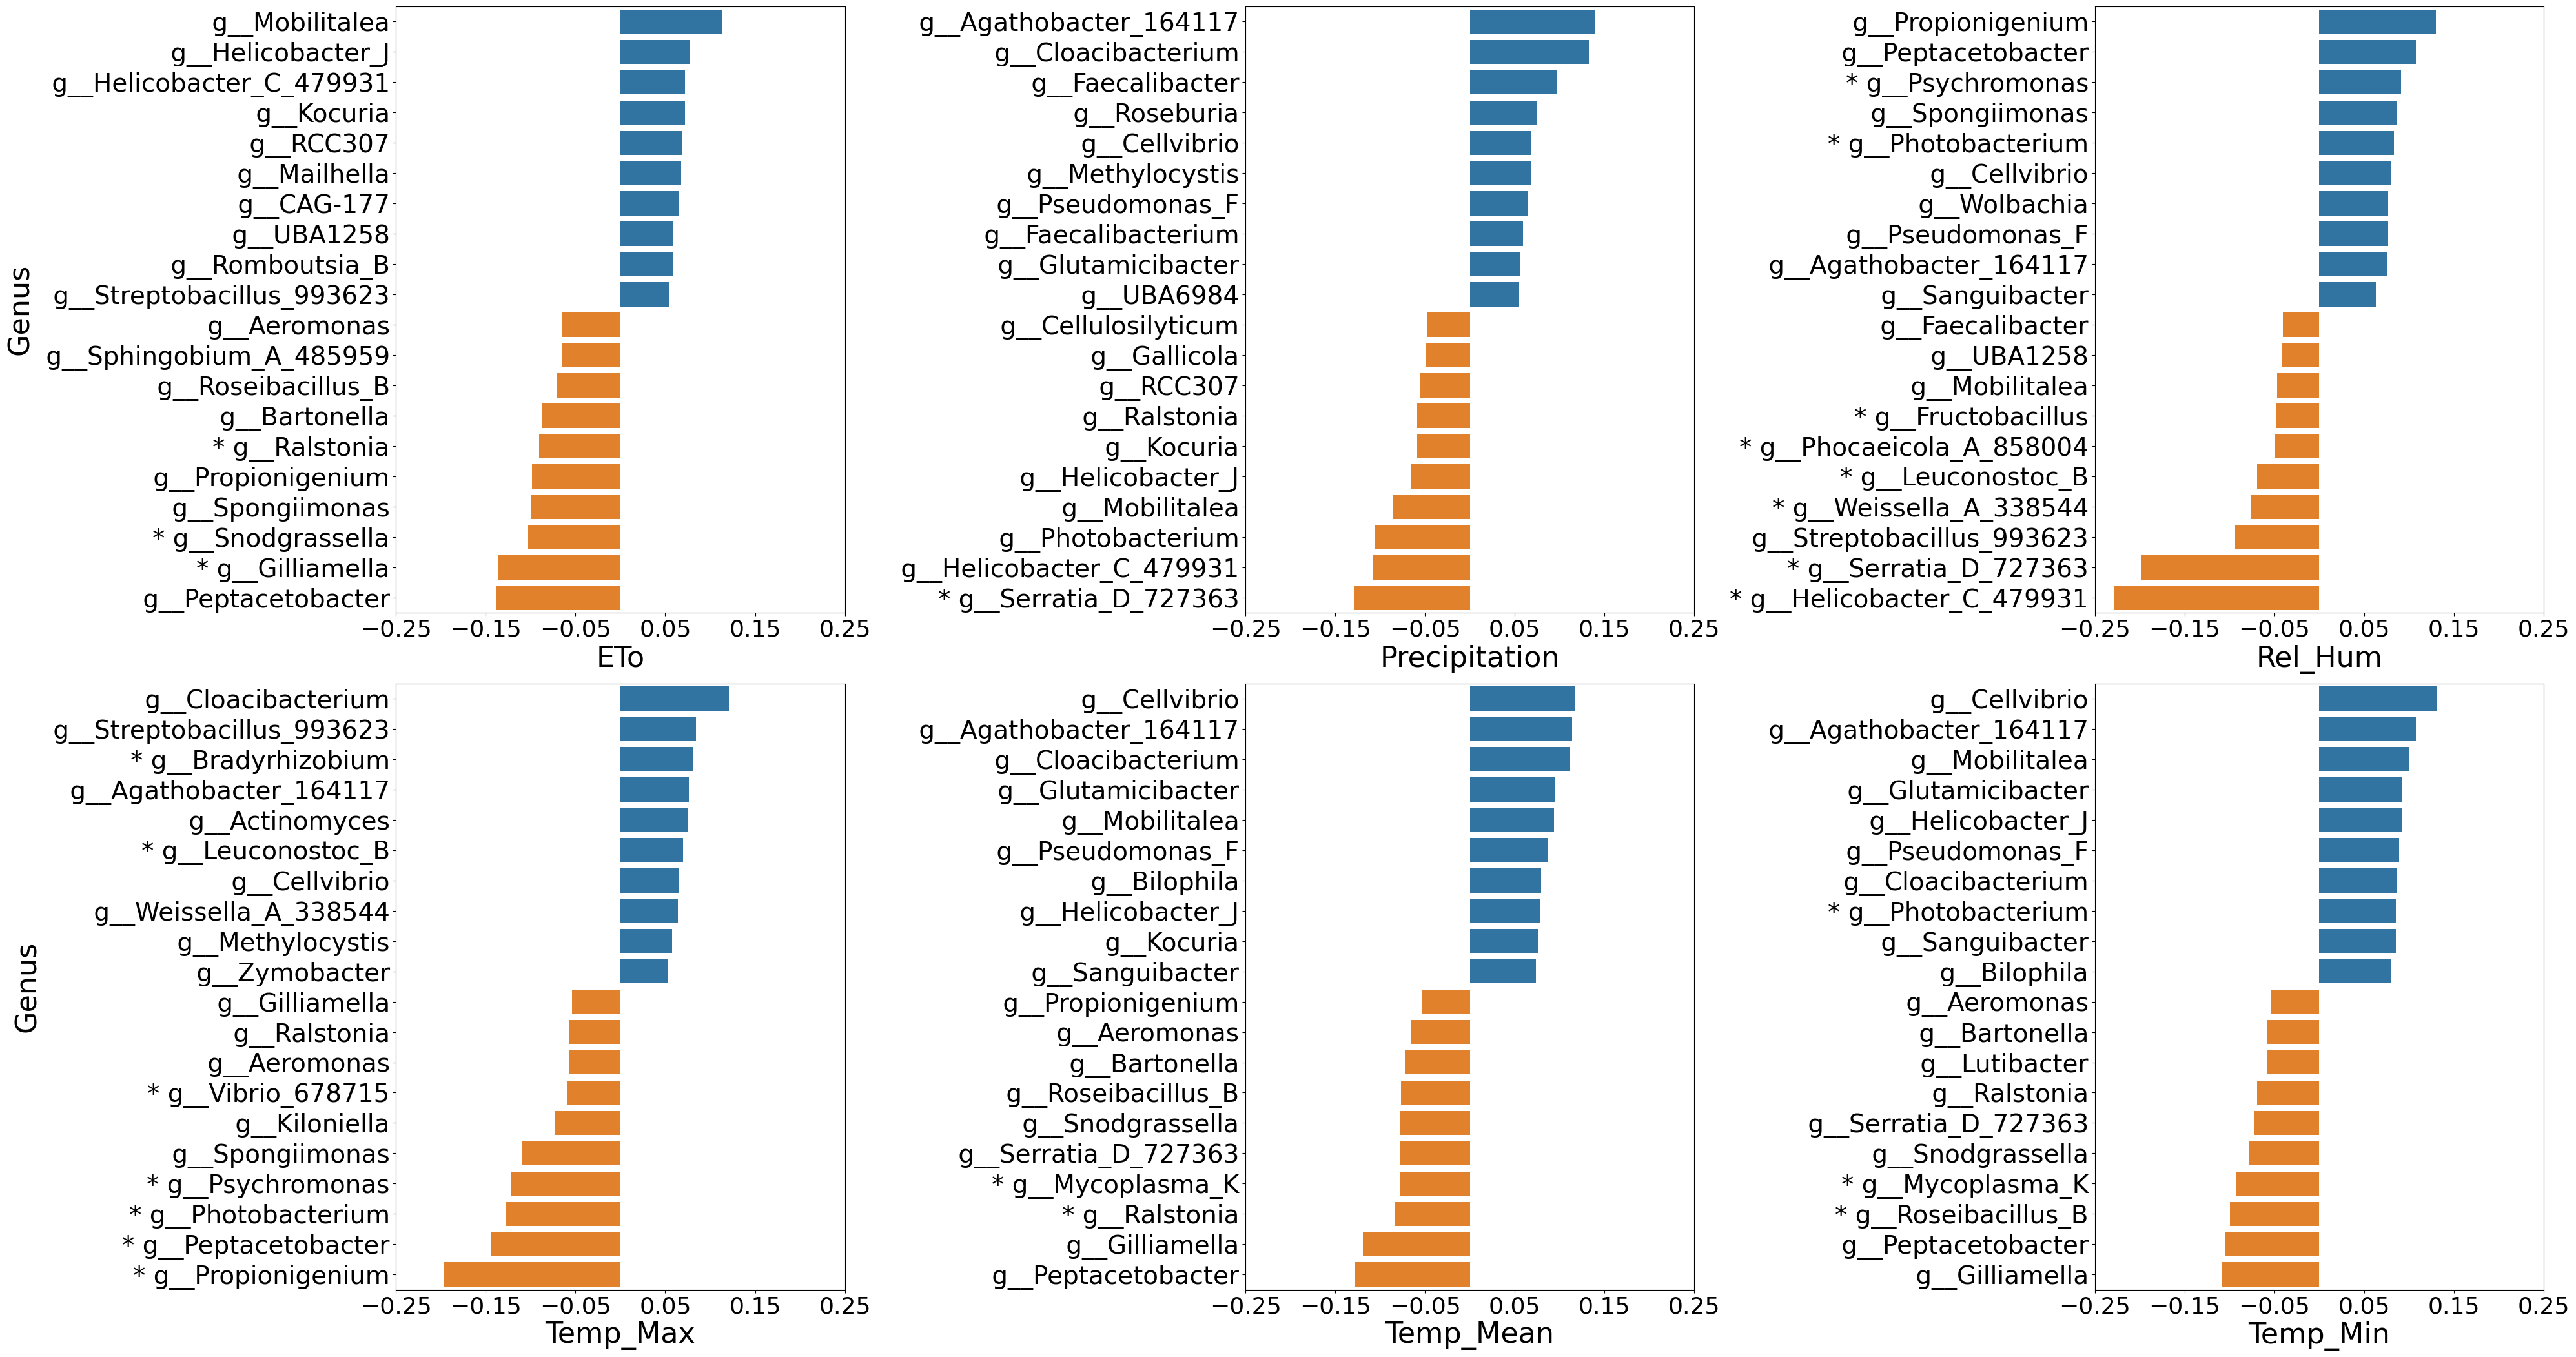

In [ ]:
# Plot 10 most positively and negatively expressed microbes by covariate w/ statistically significant microbes
fig, axes = plt.subplots(2, 3, figsize=(40, 22))
axes = axes.flatten()
for i, ax in enumerate(axes):
    cov = diff_g.columns[i]
    sns.barplot(x = cov, data = diff_g.sort_values(by=cov, ascending = False).iloc[0:10,:], y = 'Genus', ax = ax)
    sns.barplot(x = cov, data = diff.groupby('Genus').mean().sort_values(by=cov, ascending = True).iloc[0:10,:].sort_values(by=cov, ascending = False), y = 'Genus', ax = ax)
    ax.set_xlabel(cov, fontsize=32)
    ax.set_xticks([-0.25,-0.15,-0.05,0.05,0.15,0.25])
    ax.set_ylabel('Genus', fontsize=32)
    ax.tick_params(axis='y',labelsize=28)
    ax.tick_params(axis='x',labelsize=26)
    cur_y_ticks = ax.get_yticklabels()
    cur_y_ticks = genus_names = [label.get_text() for label in cur_y_ticks]
    print(cur_y_ticks)
    for j, genus in enumerate(cur_y_ticks):
        if any(sig[cov]['Genus'].str.contains(genus)):
            cur_y_ticks[j] = '*' + genus
    ax.set_yticklabels(cur_y_ticks)
    if i % 3 != 0:
        ax.set_ylabel('')
plt.tight_layout(rect=[0,0,1,0.96])

In [ ]:
# Collect significant microbes by Phylum
bact_feat = interval_df.index[interval_df.index.isin(tax[tax['Phylum'] == 'Bacteroidota']['Feature ID'])]
firm_feat = interval_df.index[interval_df.index.isin(tax[tax['Phylum'] == 'Firmicutes']['Feature ID'])]
act_feat = interval_df.index[interval_df.index.isin(tax[tax['Phylum'] == 'Actinobacteriota']['Feature ID'])]